# Projet Statapp : Feux de forêt

## Importations des librairies nécessaires

In [23]:
import pandas as pd

data = 'combine.csv'

df = pd.read_csv(data, sep=';')

In [2]:
pip install geopandas matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
!pip install requests py7zr geopandas openpyxl tqdm s3fs PyYAML xlrd
!pip install git+https://github.com/inseefrlab/cartiflette@80b8a5a28371feb6df31d55bcc2617948a5f9b1a

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 2.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.3/412.3 kB 21.6 MB/s eta 0:00:00
  Cloning https://github.com/inseefrlab/cartiflette (to revision 80b8a5a28371feb6df31d55bcc2617948a5f9b1a) to /tmp/pip-req-build-4l2b9qif
  Running command git clone --filter=blob:none --quiet https://github.com/inseefrlab/cartiflette /tmp/pip-req-build-4l2b9qif
  Running command git rev-parse -q --verify 'sha^80b8a5a28371feb6df31d55bcc2617948a

In [5]:
import cartiflette.s3 as s3

In [21]:
dep = s3.download_vectorfile_url_all(
    values = "metropole",
    crs = 4326,
    borders = "DEPARTEMENT",
    vectorfile_format="topojson",
    filter_by="FRANCE_ENTIERE",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022)

dep["area"] = dep.to_crs(2154).area

https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=DEPARTEMENT/crs=4326/FRANCE_ENTIERE=metropole/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 7.17MiB [00:00, 85.5MiB/s]


## Carte du nombre de feux par départements entre 2006 et 2022

dep contient les données gégographiques de la france et de ses départements, df contient nos données sur les feux de forêt.

In [25]:
dep['nb_feu']=0

In [26]:
valeurs_a_remplacer = {'1': '01', '2':'02','3': '03', '4': '04', '5':'05', '6':'06', '7':'07', '8':'08', '9':'09'}
df['Département'] = df['Département'].replace(valeurs_a_remplacer)

In [27]:
counts = df['Département'].value_counts().to_frame().reset_index()

On donne la valeur 0 pour les départements dont on n'a aucune données

In [28]:
counts.loc[len(counts)] = ['75', 0]

In [29]:
counts.loc[len(counts)] = ['92', 0]

In [30]:
counts.loc[len(counts)] = ['93', 0]

In [31]:
counts = counts.set_index('Département')

On ajoute une colonne à dep qui contient le nombre de feux par département

In [32]:
for i in range(0, 96):
    num = dep.loc[i, 'INSEE_DEP']
    a = counts.loc[num, 'count']
    dep.loc[i, 'nb_feu']=a

On définit notre échelle de couleur pour la carte

In [33]:
def couleur(chiffre):
    if chiffre==0:
        return 0
    elif chiffre < 100:
        return 1
    elif chiffre < 500:
        return 2
    elif chiffre < 1500:
        return 3
    else:
        return 4

In [34]:
dep['categorie']=dep['nb_feu'].apply(couleur)

Premier test d'affichage

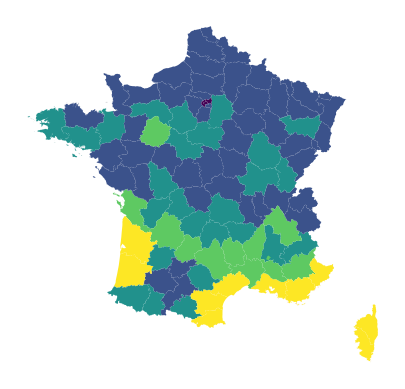

In [35]:
ax = dep.plot(column = "categorie")
ax.set_axis_off()

Deuxième essai en personnalisant les couleurs

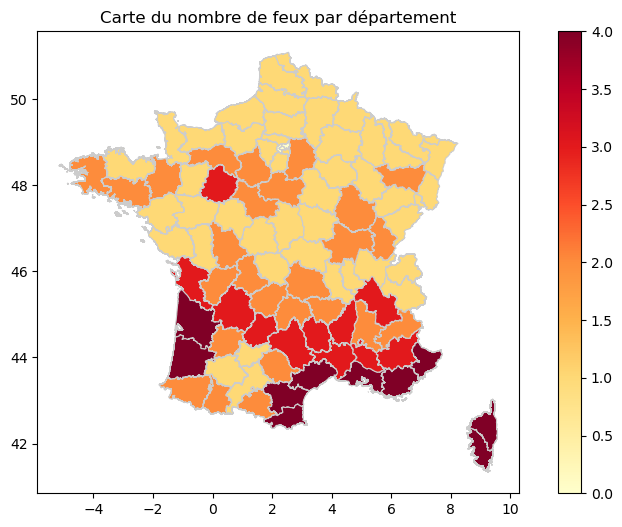

In [36]:
cmap = 'YlOrRd'

# Définir la plage de valeurs pour la colormap
vmin, vmax = dep['categorie'].min(), dep['categorie'].max()

# Créer la figure et les axes
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Utiliser la méthode plot avec l'argument cmap pour personnaliser le gradient de couleurs
ax = dep.plot(column="categorie", cmap=cmap, linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, vmin=vmin, vmax=vmax)

# Ajouter un titre à la carte
plt.title('Carte du nombre de feux par département')

# Afficher la carte
plt.show()


Troisième essai pour personnaliser la légende

/tmp/ipykernel_225/889745226.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


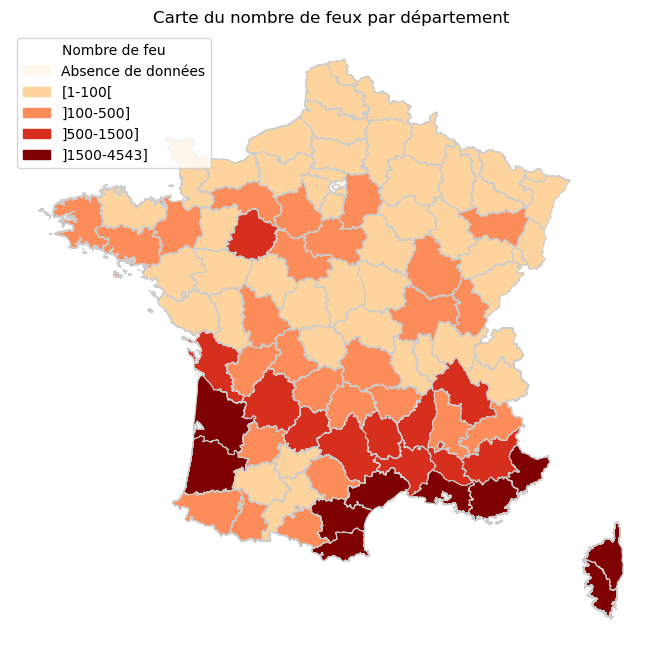

In [38]:
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

cmap_name = 'OrRd'

# Définir la plage de valeurs pour la colormap
vmin, vmax = dep['categorie'].min(), dep['categorie'].max()

# Créer la figure et les axes
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Utiliser la méthode plot avec l'argument cmap pour personnaliser le gradient de couleurs
plot = dep.plot(column="categorie", cmap=cmap_name, linewidth=0.8, ax=ax, edgecolor='0.8', legend=False, vmin=vmin, vmax=vmax)

# Récupérer les couleurs de la colormap
cmap = plt.cm.get_cmap(cmap_name)
colors = [to_rgba(cmap(i)) for i in range(cmap.N)]

# Personnaliser l'affichage de la légende
legend_labels = ['Absence de données', '[1-100[', ']100-500]', ']500-1500]', ']1500-4543]']  # Remplacez par les descriptions de votre choix
legend_patches = [Patch(color=colors[0], label=legend_labels[0]),
                  Patch(color=colors[64], label=legend_labels[1]), Patch(color=colors[128], label=legend_labels[2]), Patch(color=colors[192], label=legend_labels[3]), Patch(color=colors[255], label=legend_labels[4])]

ax.legend(handles=legend_patches, loc='upper left', title='Nombre de feu')

# Masquer les axes
ax.set_axis_off()

# Ajouter un titre à la carte
plt.title('Carte du nombre de feux par département')

# Afficher la carte
plt.show()


## Ratio surface / feux de forêt entre 2006 et 2022

In [39]:
# Calculer le nombre d'occurrences par département
counts2 = df['Département'].value_counts().to_frame().reset_index()

# Calculer la somme des surfaces par département
surface_sum = df.groupby('Département')['Surface parcourue (m2)'].sum().reset_index()
surface_sum.columns = ['Département', 'surface']

# Fusionner les deux DataFrames sur la colonne 'Département'
result = pd.merge(counts, surface_sum, on='Département')


In [41]:
def rat(count, surface):
    return surface/count if surface!=0 else 0

In [42]:
result['ratio']=result.apply(lambda row : rat(row['count'], row['surface']), axis=1)

On ajoute les valeurs manquantes

In [45]:
result.loc[len(result)] = ['93', 0, 0, 0]

In [46]:
result.loc[len(result)] = ['92', 0, 0, 0]

In [47]:
result.loc[len(result)] = ['75', 0, 0, 0]

In [48]:
result = result.set_index('Département')

On rajoute une colonne à result pour avoir accès au ration surface brulée / nb de feux

In [49]:
dep['ratio']=0

In [50]:
for i in range(0, 96):
    num = dep.loc[i, 'INSEE_DEP']
    a = result.loc[num, 'ratio']
    dep.loc[i, 'ratio']=a

/tmp/ipykernel_225/204975787.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '38783.333333333336' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dep.loc[i, 'ratio']=a


On définit l'échelle

In [51]:
def couleur_ratio(chiffre):
    if chiffre/10000 ==0:
        return 0
    elif chiffre/10000 <= 1:
        return 1
    elif chiffre/10000<= 4.6:
        return 2
    elif chiffre/10000 < 10:
        return 3
    else:
        return 4

In [52]:
dep['cat'] = dep['ratio'].apply(couleur_ratio)

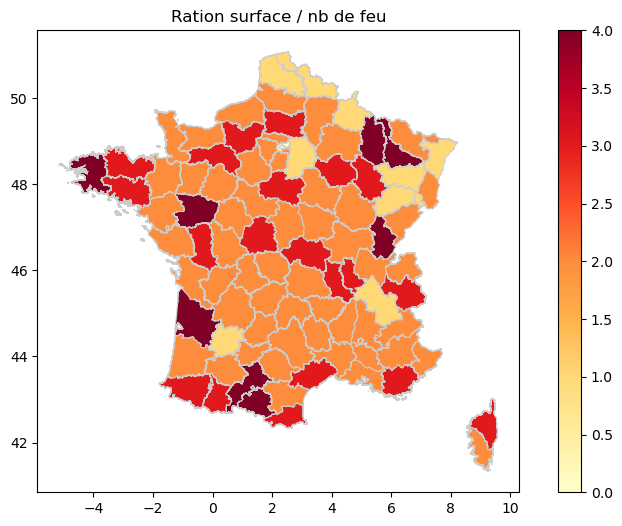

In [54]:
cmap = 'YlOrRd'

# Définir la plage de valeurs pour la colormap
vmin, vmax = dep['cat'].min(), dep['cat'].max()

# Créer la figure et les axes
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Utiliser la méthode plot avec l'argument cmap pour personnaliser le gradient de couleurs
ax = dep.plot(column="cat", cmap=cmap, linewidth=0.8, ax=ax, edgecolor='0.8', legend=True, vmin=vmin, vmax=vmax)

# Ajouter un titre à la carte
plt.title('Ration surface / nb de feu')

# Afficher la carte
plt.show()


## Carte des feux hors norme entre 2006 et 2022

In [56]:
#on choisit uniquement les feu qui ont parcouru plus 
df_hors_norme = df[df['Surface parcourue (m2)'] > 1*10**7]

In [57]:
liste = df_hors_norme['Département'].unique().tolist()

In [58]:
liste.remove('974')

In [59]:
liste

['13', '2A', '34', '66', '33', '83', '2B', '84', '11', '29', '49', '07', '48']

In [60]:
shp_communes = s3.download_vectorfile_url_all(
    crs = 4326,
    values = liste,
    borders="COMMUNE_ARRONDISSEMENT",
    vectorfile_format="topojson",
    filter_by="DEPARTEMENT",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022)

https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=13/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 866kiB [00:00, 35.1MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=2A/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 1.51MiB [00:00, 61.6MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=34/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


...

Downloading: : 1.02MiB [00:00, 52.1MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=07/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 1.62MiB [00:00, 67.8MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=48/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 1.02MiB [00:00, 53.4MiB/s]


In [61]:
villes = df_hors_norme['Code INSEE'].unique().tolist()

In [62]:
len(villes)

30

In [63]:
shp_communes = shp_communes[shp_communes['INSEE_COM'].isin(villes)]

In [64]:
# Spécifiez le chemin du fichier GeoJSON des départements
file_path = 'https://static.data.gouv.fr/resources/carte-des-departements-2-1/20191202-212236/contour-des-departements.geojson'

# Chargez les données géographiques avec GeoPandas
france_departments = gpd.read_file(file_path)


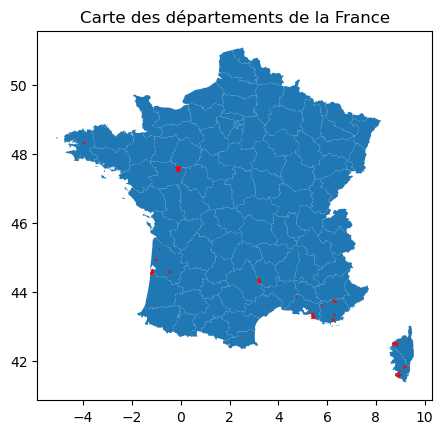

In [65]:
france_departments.plot()
plt.title('Carte des départements de la France')
shp_communes.plot(marker='o', color='red', markersize=5, ax=plt.gca())
plt.show()

Deuxième test pour avoir un affichage en fonction de la taille du feu

In [66]:
shp_communes['taille incendie']=0

In [67]:
shp_communes = shp_communes.reset_index()

In [68]:
df_hors_norme = df_hors_norme.sort_values(by='Surface parcourue (m2)', ascending=False)
df_hors_norme = df_hors_norme.drop_duplicates(subset='Code INSEE', keep='first')

In [69]:
df_hors_norme = df_hors_norme.set_index('Code INSEE')

In [70]:
len(shp_communes['INSEE_COM'])

42

In [71]:
df_hors_norme.loc['33225', 'Surface parcourue (m2)']

125520000

In [72]:
for i in range(0, 42):
    com = shp_communes.loc[i, 'INSEE_COM']
    taille = df_hors_norme.loc[com, 'Surface parcourue (m2)']
    shp_communes.loc[i, 'taille incendie']=taille

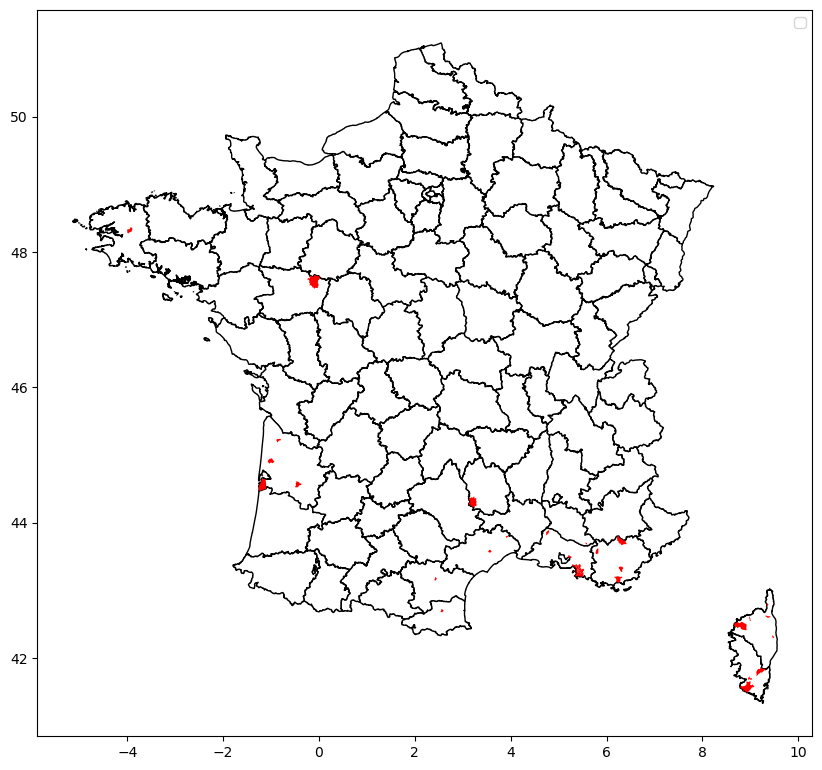

In [73]:
# Plot du fond de carte
ax = france_departments.plot(figsize=(10, 10), edgecolor='black', color='white')

# Plot des marqueurs de taille proportionnelle
shp_communes.plot(ax=ax, marker='o', color='red', markersize=shp_communes['taille incendie']*10)

# Ajoutez une légende si nécessaire
ax.legend(["Fond de carte", "Marqueurs d'incendie"])

# Affichez la carte 
plt.show()


On n'a toujours pas l'affichage voulu mais les communes concernées sont les bonnes

# Différence des feux entre 2006-2021 et 2022

*Moyenne en 2022*

In [74]:
# Filtrer le DataFrame pour ne conserver que les lignes où l'année est 2022
df_2022 = df[df['Année'] == 2022]

# Calculer la somme de la surface parcourue par département en 2022
surface_par_departement_2022 = df_2022.groupby('Département')['Surface parcourue (m2)'].sum().reset_index()

# Renommer les colonnes
surface_par_departement_2022.columns = ['Département', 'Surface_moyenne_2022']

# Convertir la surface de mètres carrés en hectares
surface_par_departement_2022['Surface_hectares_2022'] = surface_par_departement_2022['Surface_moyenne_2022'] / 10000

surface_par_departement_2022.head()  #df avec la moyenne de surface brûlée en 2022 pour chaque département

,Département,Surface_moyenne_2022,Surface_hectares_2022
0,01,145000,14.5000
1,02,110000,11.0000
2,03,20,0.0020
3,04,13358135,1335.8135
4,05,995435,99.5435


On complète les valeurs manquantes

In [75]:
surface_par_departement_2022.loc[len(surface_par_departement_2022)] = ['25', 0,0]

In [76]:
surface_par_departement_2022.loc[len(surface_par_departement_2022)] = ['51', 0,0]

In [77]:
surface_par_departement_2022.loc[len(surface_par_departement_2022)] = ['75', 0,0]

In [78]:
surface_par_departement_2022.loc[len(surface_par_departement_2022)] = ['92', 0,0]

In [79]:
surface_par_departement_2022.loc[len(surface_par_departement_2022)] = ['93', 0,0]

In [80]:
surface_par_departement_2022.loc[len(surface_par_departement_2022)] = ['94', 0,0]

In [81]:
dep['Surface_2022'] = 0

In [82]:
surface_par_departement_2022= surface_par_departement_2022.set_index('Département')

In [83]:
for i in range(0,96):
    num = dep.loc[i,'INSEE_DEP']
    a = surface_par_departement_2022.loc[num,'Surface_hectares_2022']
    dep.loc[i,'Surface_2022'] = a

/tmp/ipykernel_225/2537370069.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '14.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dep.loc[i,'Surface_2022'] = a


In [84]:
def couleur_surface(chiffre):
    if chiffre==0:
        return 0
    elif chiffre < 10:
        return 1
    elif chiffre < 100:
        return 2
    elif chiffre < 1000:
        return 3
    elif chiffre < 10000:
        return 4
    else:
        return 5

/tmp/ipykernel_225/3191653313.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


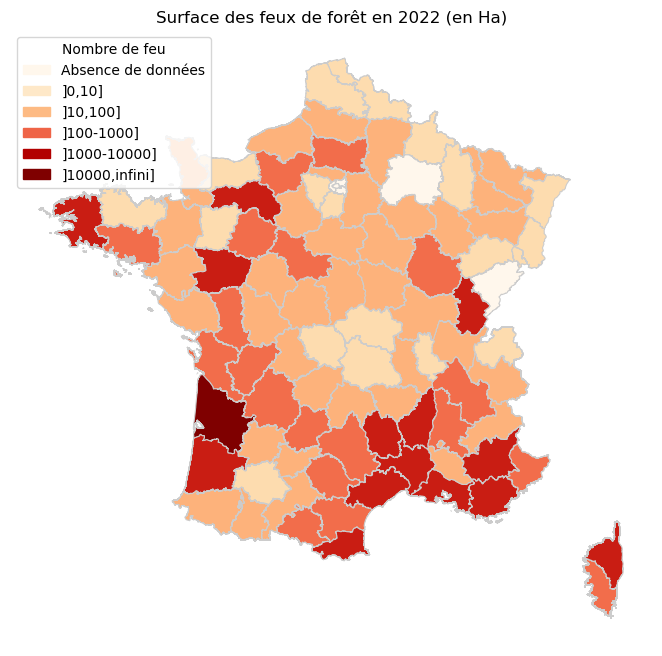

In [85]:
dep['categorie_2022']=dep['Surface_2022'].apply(couleur_surface)

from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

# Supposons que "dep" est votre GeoDataFrame et "nb_feu" est la colonne que vous voulez représenter
# Vous pouvez remplacer la colormap par celle de votre choix, par exemple "viridis", "plasma", "inferno", etc.
cmap_name = 'OrRd'

# Définir la plage de valeurs pour la colormap
vmin, vmax = dep['categorie_2022'].min(), dep['categorie_2022'].max()

# Créer la figure et les axes
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Utiliser la méthode plot avec l'argument cmap pour personnaliser le gradient de couleurs
plot = dep.plot(column="categorie_2022", cmap=cmap_name, linewidth=0.8, ax=ax, edgecolor='0.8', legend=False, vmin=vmin, vmax=vmax)

# Récupérer les couleurs de la colormap
cmap = plt.cm.get_cmap(cmap_name)
colors = [to_rgba(cmap(i)) for i in range(cmap.N)]

# Personnaliser l'affichage de la légende
legend_labels = ['Absence de données', ']0,10]', ']10,100]', ']100-1000]', ']1000-10000]',']10000,infini]']  # Remplacez par les descriptions de votre choix
legend_patches = [Patch(color=colors[0], label=legend_labels[0]),
                  Patch(color=colors[32], label=legend_labels[1]), Patch(color=colors[96], label=legend_labels[2]), Patch(color=colors[160], label=legend_labels[3]), Patch(color=colors[224], label=legend_labels[4]),Patch(color=colors[255], label=legend_labels[5])]

ax.legend(handles=legend_patches, loc='upper left', title='Nombre de feu')

# Masquer les axes
ax.set_axis_off()

# Ajouter un titre à la carte
plt.title('Surface des feux de forêt en 2022 (en Ha)')

# Afficher la carte
plt.show()

*Moyenne de 2006 à 2021*

In [86]:
df['Année'] = pd.to_numeric(df['Année'], errors='coerce')

# Surface annuelle parcourue par département par année 
df_surface_moyenne_par_an = df[df['Année'] <= 2021].groupby(['Département', 'Année'])['Surface parcourue (m2)'].sum().reset_index()

# Renommer les colonnes
df_surface_moyenne_par_an.columns = ['Département', 'Année', 'Moyenne_Surface']

df_surface_moyenne_par_an['Surface_hectares_moyenne'] = df_surface_moyenne_par_an['Moyenne_Surface'] / 10000

# Afficher le nouveau DataFrame avec la moyenne annuelle
print(df_surface_moyenne_par_an.head())


  Département  Année  Moyenne_Surface  Surface_hectares_moyenne
0          01   2006           270000                      27.0
1          01   2007           165000                      16.5
2          01   2008           267000                      26.7
3          01   2012           130000                      13.0
4          01   2015           130000                      13.0


In [87]:
# Calculer la moyenne par département des surfaces brûlées de 2006 à 2021 (moyenne des moyennes)
df_moyenne_totale = df_surface_moyenne_par_an.groupby('Département')['Surface_hectares_moyenne'].mean().reset_index()

# Renommer les colonnes
df_moyenne_totale.columns = ['Département', 'Moyenne_Surface']

# Afficher le nouveau DataFrame avec la moyenne par département
print(df_moyenne_totale)

   Département  Moyenne_Surface
0           01        21.820000
1           02        15.300500
2           03        39.711000
3           04       144.703213
4           05        25.659194
..         ...              ...
88          91        19.230000
89          94         2.000000
90          95         0.088333
91         974       437.657956
92         976       282.692200

[93 rows x 2 columns]


In [88]:
df_moyenne_totale.loc[len(df_moyenne_totale)] = ['20',0]

In [89]:
df_moyenne_totale.loc[len(df_moyenne_totale)] = ['44',0]

In [90]:
df_moyenne_totale.loc[len(df_moyenne_totale)] = ['59',0]

In [91]:
df_moyenne_totale.loc[len(df_moyenne_totale)] = ['75',0]

In [92]:
df_moyenne_totale.loc[len(df_moyenne_totale)] = ['92',0]

In [93]:
df_moyenne_totale.loc[len(df_moyenne_totale)] = ['93',0]

In [94]:
df_moyenne_totale= df_moyenne_totale.set_index('Département')

In [95]:
dep['Surface_moyenne_anuelle'] = 0

for i in range(0,96):
    num = dep.loc[i,'INSEE_DEP']
    #print(num)
    a = df_moyenne_totale.loc[num,'Moyenne_Surface']
    #print("la surface de l'incendie était de", a)
    dep.loc[i,'Surface_moyenne_anuelle'] = a

/tmp/ipykernel_225/3153304344.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.82' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dep.loc[i,'Surface_moyenne_anuelle'] = a


In [96]:
def couleur_surface_moyenne(chiffre):
    if chiffre==0:
        return 0
    elif chiffre <= 10:
        return 1
    elif chiffre <= 100:
        return 2
    elif chiffre <= 1000:
        return 3
    elif chiffre <= 1280:
        return 4

/tmp/ipykernel_225/3402564770.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


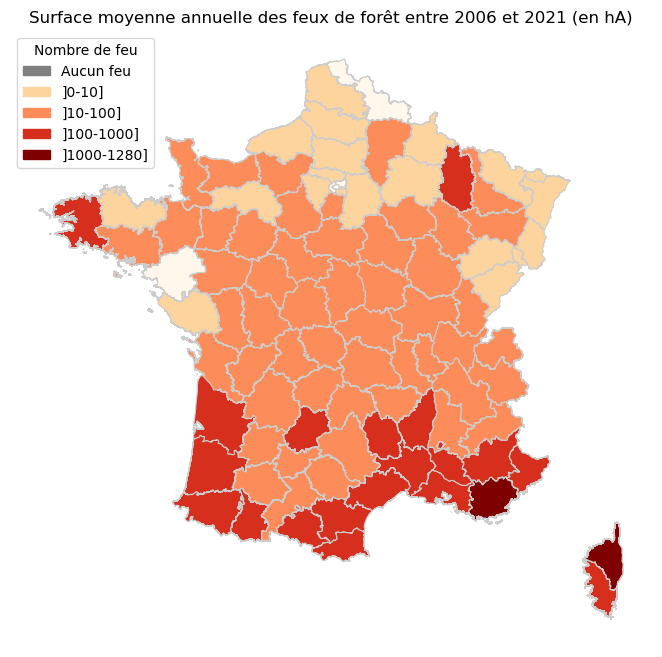

In [97]:
dep['categorie_moyenne']=dep['Surface_moyenne_anuelle'].apply(couleur_surface_moyenne)

from matplotlib.colors import to_rgba
from matplotlib.patches import Patch
# Supposons que "dep" est votre GeoDataFrame et "nb_feu" est la colonne que vous voulez représenter
# Vous pouvez remplacer la colormap par celle de votre choix, par exemple "viridis", "plasma", "inferno", etc.
cmap_name = 'OrRd'

# Définir la plage de valeurs pour la colormap
vmin, vmax = dep['categorie_moyenne'].min(), dep['categorie_moyenne'].max()

# Créer la figure et les axes
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Utiliser la méthode plot avec l'argument cmap pour personnaliser le gradient de couleurs
plot = dep.plot(column="categorie_moyenne", cmap=cmap_name, linewidth=0.8, ax=ax, edgecolor='0.8', legend=False, vmin=vmin, vmax=vmax)

# Récupérer les couleurs de la colormap
cmap = plt.cm.get_cmap(cmap_name)
colors = [to_rgba(cmap(i)) for i in range(cmap.N)]

# Personnaliser l'affichage de la légende
legend_labels = ['Aucun feu', ']0-10]', ']10-100]', ']100-1000]', ']1000-1280]']
legend_patches = [Patch(color='gray', label=legend_labels[0]),
                  Patch(color=colors[64], label=legend_labels[1]),
                  Patch(color=colors[128], label=legend_labels[2]),
                  Patch(color=colors[192], label=legend_labels[3]),
                  Patch(color=colors[255], label=legend_labels[4])]

ax.legend(handles=legend_patches, loc='upper left', title='Nombre de feu')

# Masquer les axes
ax.set_axis_off()

# Ajouter un titre à la carte
plt.title('Surface moyenne annuelle des feux de forêt entre 2006 et 2021 (en hA)')

# Afficher la carte
plt.show()

## Feux de forêt le 18 juillet 2022

In [110]:
df['Date'] = pd.to_datetime(df['Date de première alerte'], format='%d/%m/%Y %H:%M')

df_juillet = df[df['Date de première alerte'].dt.date == pd.to_datetime('18/07/2022', format='%d/%m/%Y').date()]

In [112]:
liste2 = df_juillet['Département'].unique().tolist()

In [114]:
shp_communes2 = s3.download_vectorfile_url_all(
    crs = 4326,
    values = liste2,
    borders="COMMUNE_ARRONDISSEMENT",
    vectorfile_format="topojson",
    filter_by="DEPARTEMENT",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022)

https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=49/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 1.02MiB [00:00, 53.4MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=43/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 1.16MiB [00:00, 57.1MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=71/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


...

Downloading: : 1.18MiB [00:00, 59.1MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=84/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 598kiB [00:00, 38.5MiB/s]


https://minio.lab.sspcloud.fr/projet-cartiflette/diffusion/shapefiles-test1/year=2022/administrative_level=COMMUNE_ARRONDISSEMENT/crs=4326/DEPARTEMENT=57/vectorfile_format=topojson/provider=IGN/source=EXPRESS-COG-CARTO-TERRITOIRE/raw.topojson


Downloading: : 1.64MiB [00:00, 55.3MiB/s]
